# 1. Header & imports

In [1]:
# 04_fairness_analysis.ipynb
# Fairness evaluation for NHANES diabetes risk model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score

import joblib

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 100)

# 2. Load data, model, and scaler

In [2]:
# ---- Load cleaned NHANES dataset ----
nhanes = pd.read_csv("../data/nhanes_clean.csv")
print("NHANES shape:", nhanes.shape)
nhanes.head()

NHANES shape: (10761, 12)


,SEQN,RIAGENDR,RIDAGEYR,INDFMPIR,BMXBMI,LBXGH,LBXGLU,diabetes_label,race_2.0,race_3.0,race_4.0,race_5.0
0,62161.0,0.0,22.0,3.15,23.3,5.1,92.0,0.0,False,True,False,False
1,62164.0,1.0,44.0,1.67,23.2,4.9,82.0,0.0,False,True,False,False
2,62165.0,1.0,14.0,0.57,27.2,5.9,88.0,0.0,False,False,True,False
3,62169.0,0.0,21.0,0.33,20.1,5.4,107.0,0.0,False,False,False,True
4,62170.0,0.0,15.0,5.00,18.2,5.2,99.0,0.0,False,False,False,True


In [3]:
# Separate features/target
X_nh_all = nhanes.drop("diabetes_label", axis=1)
y_nh_all = nhanes["diabetes_label"]

# Train/test split (same as before)
X_nh_train, X_nh_test, y_nh_train, y_nh_test = train_test_split(
    X_nh_all, y_nh_all,
    test_size=0.2,
    random_state=42,
    stratify=y_nh_all
)

X_nh_train.shape, X_nh_test.shape

((8608, 11), (2153, 11))

In [4]:
# Load scaler and tuned XGBoost model
nhanes_scaler = joblib.load("../models/nhanes_scaler.pkl")          # or nhanes_scaler_tuned.pkl if that's what you saved
nhanes_xgb_tuned = joblib.load("../models/nhanes_xgb_tuned.pkl")

# Scale test set
X_nh_test_scaled = nhanes_scaler.transform(X_nh_test)

# Predictions & probabilities on TEST SET
y_nh_pred = nhanes_xgb_tuned.predict(X_nh_test_scaled)
y_nh_proba = nhanes_xgb_tuned.predict_proba(X_nh_test_scaled)[:, 1]

print("Test AUC:", roc_auc_score(y_nh_test, y_nh_proba))

Test AUC: 0.9469243422425958


# 3. Helper: compute group fairness metrics

In [5]:
def compute_group_fairness(y_true, y_pred, y_proba, group_values, group_name="group"):
    """
    y_true, y_pred, y_proba: arrays for the test set
    group_values: array/Series same length, specifying the group for each row
    """
    df = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
        "y_proba": y_proba,
        group_name: group_values
    })

    rows = []
    for g, sub in df.groupby(group_name):
        yt = sub["y_true"].values
        yp = sub["y_pred"].values

        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()

        n = len(sub)
        pos_rate = yt.mean() if n > 0 else np.nan                # actual prevalence
        pred_pos_rate = yp.mean() if n > 0 else np.nan           # demographic parity

        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan        # equal opportunity
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan        # precision

        rows.append({
            group_name: g,
            "n": n,
            "pos_rate": pos_rate,
            "pred_pos_rate": pred_pos_rate,
            "TPR": tpr,
            "FPR": fpr,
            "PPV": ppv
        })

    return pd.DataFrame(rows)

# 4. Fairness by Gender

In [6]:
# Attach demographic columns from X_nh_test
X_nh_test_with_demo = X_nh_test.copy()  # same indices as y_nh_test

# Check gender distribution
X_nh_test_with_demo["RIAGENDR"].value_counts()

RIAGENDR
1.0    1097
0.0    1056
Name: count, dtype: int64

In [7]:
# Map to labels for readability
gender_labels = X_nh_test_with_demo["RIAGENDR"].map({0: "Female", 1: "Male"})

gender_fairness = compute_group_fairness(
    y_true=y_nh_test,
    y_pred=y_nh_pred,
    y_proba=y_nh_proba,
    group_values=gender_labels,
    group_name="gender"
)

gender_fairness

,gender,n,pos_rate,pred_pos_rate,TPR,FPR,PPV
0,Female,1056,0.124053,0.103220,0.648855,0.025946,0.779817
1,Male,1097,0.110301,0.089335,0.661157,0.018443,0.816327


## Plot demographic parity & TPR gaps:

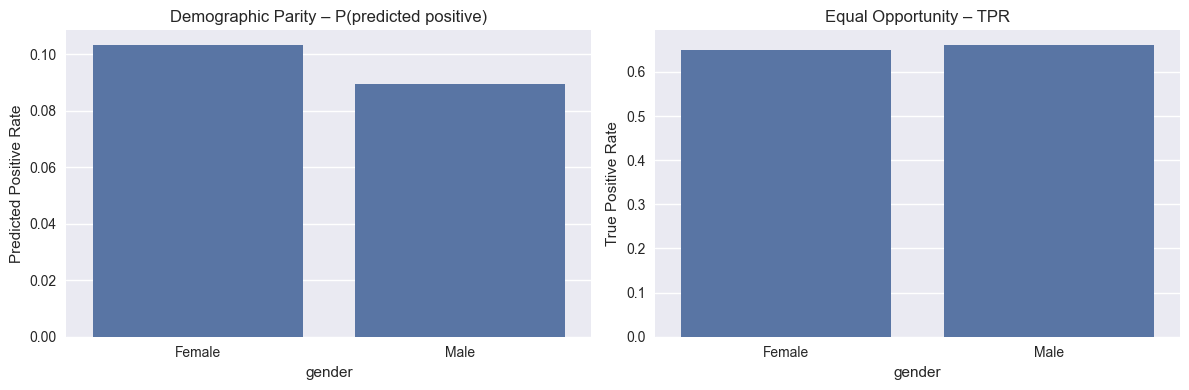

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.barplot(data=gender_fairness, x="gender", y="pred_pos_rate", ax=axes[0])
axes[0].set_title("Demographic Parity – P(predicted positive)")
axes[0].set_ylabel("Predicted Positive Rate")

sns.barplot(data=gender_fairness, x="gender", y="TPR", ax=axes[1])
axes[1].set_title("Equal Opportunity – TPR")
axes[1].set_ylabel("True Positive Rate")

plt.tight_layout()

plt.savefig(
    "../figures/fairness/_gender.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 5. Fairness by Age Group

In [9]:
# Create age groups on the TEST SET
age = X_nh_test_with_demo["RIDAGEYR"]

age_bins = [18, 40, 60, 80, 120]
age_labels = ["18–39", "40–59", "60–79", "80+"]

age_group = pd.cut(age, bins=age_bins, labels=age_labels, right=False)

age_fairness = compute_group_fairness(
    y_true=y_nh_test,
    y_pred=y_nh_pred,
    y_proba=y_nh_proba,
    group_values=age_group,
    group_name="age_group"
)

age_fairness

C:\Users\windows 11\AppData\Local\Temp\ipykernel_12944\821809120.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for g, sub in df.groupby(group_name):


,age_group,n,pos_rate,pred_pos_rate,TPR,FPR,PPV
0,18–39,658,0.019757,0.019757,0.692308,0.006202,0.692308
1,40–59,607,0.136738,0.110379,0.626506,0.028626,0.776119
2,60–79,475,0.263158,0.210526,0.648000,0.054286,0.810000
3,80+,102,0.303922,0.264706,0.741935,0.056338,0.851852


### Plots:

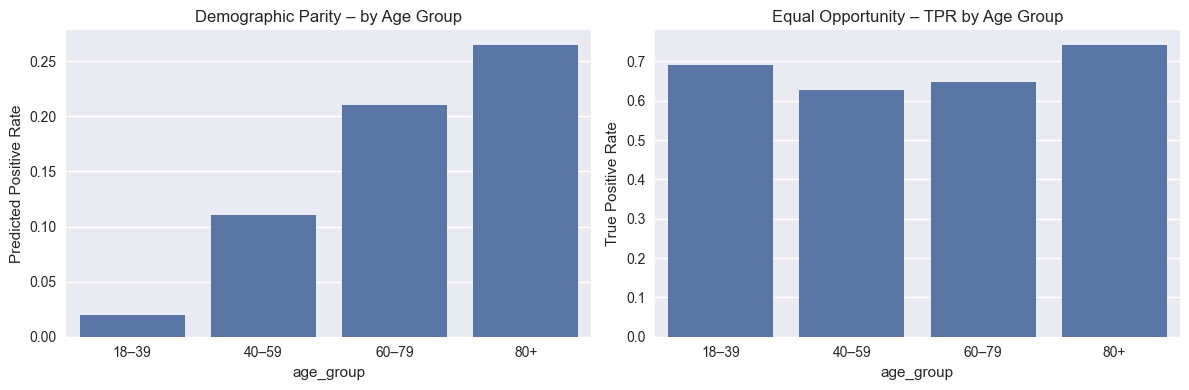

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.barplot(data=age_fairness, x="age_group", y="pred_pos_rate", ax=axes[0])
axes[0].set_title("Demographic Parity – by Age Group")
axes[0].set_ylabel("Predicted Positive Rate")

sns.barplot(data=age_fairness, x="age_group", y="TPR", ax=axes[1])
axes[1].set_title("Equal Opportunity – TPR by Age Group")
axes[1].set_ylabel("True Positive Rate")

plt.tight_layout()

plt.savefig(
    "../figures/fairness/dp_gender.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 6. Fairness by Race/Ethnicity

In [12]:
# Example: majority vs minority
race_cols = [c for c in X_nh_test_with_demo.columns if c.startswith("race_")]
race_cols

['race_2.0', 'race_3.0', 'race_4.0', 'race_5.0']

In [13]:
if len(race_cols) > 0:
    # First dummy as "group A", rest as "group B" just for demonstration
    main_race = race_cols[0]
    majority = X_nh_test_with_demo[main_race] == 1
    race_group = np.where(majority, "Group A", "Other")

    race_fairness = compute_group_fairness(
        y_true=y_nh_test,
        y_pred=y_nh_pred,
        y_proba=y_nh_proba,
        group_values=race_group,
        group_name="race_group"
    )

    race_fairness

# 7. Fairness gaps for gender, age, and race

In [15]:
def compute_gaps_vs_reference(fair_df, group_col, ref_group=None):
    """
    fair_df: output from compute_group_fairness(...)
    group_col: name of the column containing the group labels
    ref_group: label of the reference group. If None, the group with largest n is used.
    """
    df = fair_df.set_index(group_col)

    if ref_group is None:
        # choose the majority group by sample size
        ref_group = df["n"].idxmax()

    dp_diff = df["pred_pos_rate"] - df.loc[ref_group, "pred_pos_rate"]
    eo_diff = df["TPR"] - df.loc[ref_group, "TPR"]

    gaps = pd.DataFrame({
        "group": df.index,
        "reference": ref_group,
        "DP_diff_vs_ref": dp_diff.values,
        "EO_diff_vs_ref": eo_diff.values
    })
    return gaps

## 7.1 Gender gaps (reference = Male)

In [16]:
fairness_gaps_gender = compute_gaps_vs_reference(
    gender_fairness,
    group_col="gender",
    ref_group="Male"   # or "Female" if you prefer
)

fairness_gaps_gender

,group,reference,DP_diff_vs_ref,EO_diff_vs_ref
0,Female,Male,0.013885,-0.012302
1,Male,Male,0.000000,0.000000


## 7.2 Age-group gaps (reference = majority age group)

In [17]:
fairness_gaps_age = compute_gaps_vs_reference(
    age_fairness,
    group_col="age_group",   # column from age_fairness
    ref_group=None           # automatically picks group with largest n
)

fairness_gaps_age

,group,reference,DP_diff_vs_ref,EO_diff_vs_ref
0,18–39,18–39,0.000000,0.000000
1,40–59,18–39,0.090622,-0.065802
2,60–79,18–39,0.190769,-0.044308
3,80+,18–39,0.244949,0.049628


## 7.3 Race gaps (reference = majority race group)

In [19]:
fairness_gaps_race = compute_gaps_vs_reference(
    race_fairness,
    group_col="race_group",
    ref_group=None
)

fairness_gaps_race

,group,reference,DP_diff_vs_ref,EO_diff_vs_ref
0,Group A,Other,0.015104,0.170524
1,Other,Other,0.000000,0.000000


# 8. Fairness heatmaps for gender, age, and race

## 8.1 Helper function for heatmap

In [36]:
def plot_fairness_heatmap(fair_df, group_col, title):
    metrics_for_heatmap = fair_df.set_index(group_col)[["pred_pos_rate", "TPR", "FPR", "PPV"]]

    plt.figure(figsize=(6,4))
    sns.heatmap(metrics_for_heatmap, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title(title)
    plt.ylabel(group_col)
    plt.show()

## 8.2 Gender fairness heatmap

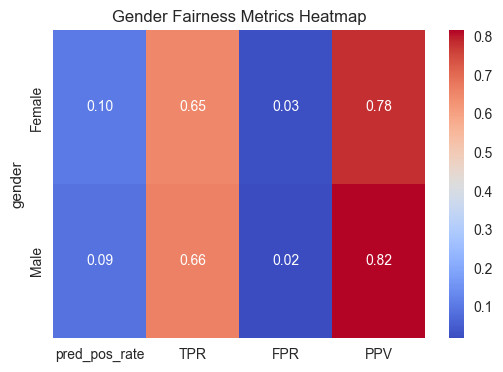

In [37]:
plot_fairness_heatmap(
    gender_fairness,
    group_col="gender",
    title="Gender Fairness Metrics Heatmap"
)

fig.savefig(
    "../figures/fairness/gender_fairness_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 8.3 Age-group fairness heatmap

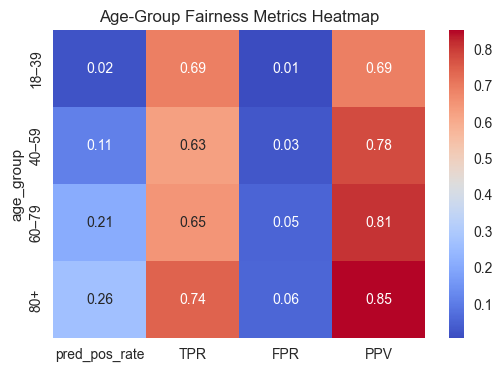

In [22]:
plot_fairness_heatmap(
    age_fairness,
    group_col="age_group",
    title="Age-Group Fairness Metrics Heatmap"
)

## 8.4 Race fairness heatmap

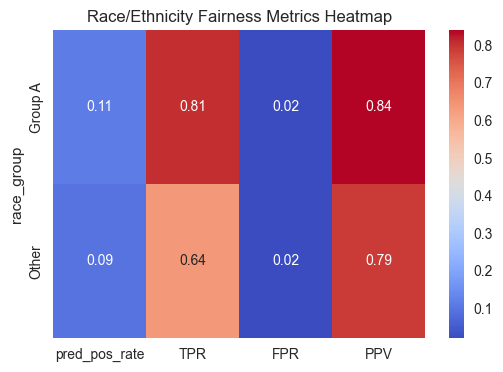

In [24]:
plot_fairness_heatmap(
    race_fairness,
    group_col="race_group",   
    title="Race/Ethnicity Fairness Metrics Heatmap"
)